# **Markov Decision Processes**

### 1. Introduction to MDPs

In the last notebook, we introduced MAB problems that acquainted us with RL fundamentals such as actions, rewards and the trade-off between exploration and exploitation. However, MABs are simplistic in that each one-armed bandit has a fixed reward distribution. In other words, rewards given to the agent are not dependent on the previously taken actions (which bandit machines were pulled beforehand). To discuss problems where this is not the case, previous actions taken by the agent do change the distribution of expected rewards, we will consider Markov Decision Processes (MDPs).

MDPs can be viewed of as extentions of Markov chains.

### 2. Markov Chain Basics

Markov chains allow us to model sequences of possible events where the probability of an event occuring depends only on the event that occured before it it. In the language of Markov chains, an event is when the described system transitions into a state. As an example, let us consider the following system which can only exist in two states: $A$ and $E$,

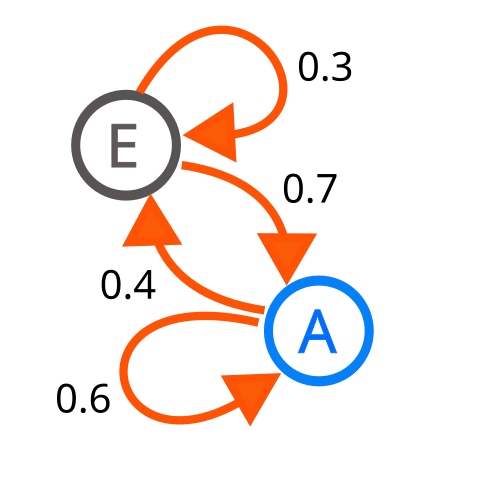

In total, we have four transition probabilities describing the transition. They are:
- (a) $A \longrightarrow E$ 
- (b) $E \longrightarrow A$ 
- (c) $A \longrightarrow A$
- (d) $E \longrightarrow E$

Notice that we include transitions that begin and end with the systems in the same state. Each transition has probability of occuring. For example, $A \longrightarrow E$ has the transition probability $P(E \vert A) = 0.4$. On our node diagram, all the probabilities from a node must sun up to one such that probability is conserved. We can take random walks along a chain by sequentially considering the probability of each transition. From this random walk, we can compute the probability of the system being in a given state. In our case, we have $P(A)$ and $P(E)$. Let us use Python to simulate this, 

In [12]:
# Importing,
import numpy as np

def next_state(current_state):
    """Returns the next state of the system provides the current state. 0 represents state A while 1 refers to state E."""

    # Current state is A,
    if current_state == 0:
        if np.random.uniform(low=0, high=1, size=1) < 0.4:
            next_state = 1
        else:
            next_state = 0

    # Current state is E,
    if current_state == 1:
        if np.random.uniform(low=0, high=1, size=1) < 0.3:
            next_state = 1
        else:
            next_state = 0

    return next_state

# Simulating random walk,
N = 10000

current_state = 0
count = 0
for t in range(N):
    current_state = next_state(current_state)
    count += current_state

probs_E = count/N
print(f"P(E) = {(probs_E)}, P(A) = {(1-probs_E)}")

P(E) = 0.3652, P(A) = 0.6348


Notice that for large $N$, the number of iterations in the random walk, $P(A)$ and $P(E)$ reach stable values.

### References

Lecture 16: Markov Chains - https://www.youtube.com/watch?v=IkbkEtOOC1Y

# A. Markov Chains

Let us consider the equations that describe physical systems. Given some previous state $s_{t-1}$ of a system, there exists some equation $f$, or set of equations, that determines how the system evolves into a new state $s_t$. In classical mechanics, these equations may arise from Newton’s laws of motion, or from the Lagrangian or Hamiltonian formulations of mechanics. In quantum mechanics, the evolution may instead be described by the time-evolution operator acting on the quantum state.